In [1]:
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
path_normal = r'Dataset\Normal_chest'
path_tuberclosis = r'Dataset\Tuberclosis_chest'

In [3]:
image_df = pd.DataFrame({'Image_id':[],'Height':[],'Width':[],'Tuberclosis':[]})

In [4]:
i = 1

In [5]:
for image_file in os.listdir(path_normal):
    path = os.path.join(path_normal,image_file)
    with Image.open(path) as img:
        size = tuple(img.size)
        height = size[0]
        width = size[1]
    tbcls = 0
    image_df = pd.concat([image_df,pd.DataFrame([{'Image_id':f'image{i}','Height':height,'Width':width,'Tuberclosis':tbcls}])],ignore_index=True)
    i += 1

In [6]:
for image_file in os.listdir(path_tuberclosis):
    path = os.path.join(path_tuberclosis,image_file)
    with Image.open(path) as img:
        size = tuple(img.size)
        height = size[0]
        width = size[1]
    tbcls = 1
    image_df = pd.concat([image_df,pd.DataFrame([{'Image_id':f'image{i}','Height':height,'Width':width,'Tuberclosis':tbcls}])],ignore_index=True)
    i += 1

In [7]:
image_df.head()

,Image_id,Height,Width,Tuberclosis
0,image1,256.0,256.0,0.0
1,image2,256.0,256.0,0.0
2,image3,256.0,256.0,0.0
3,image4,256.0,256.0,0.0
4,image5,256.0,256.0,0.0


In [8]:
image_df['Tuberclosis'] = image_df['Tuberclosis'].astype(int)

In [9]:
image_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3008 entries, 0 to 3007
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Image_id     3008 non-null   object 
 1   Height       3008 non-null   float64
 2   Width        3008 non-null   float64
 3   Tuberclosis  3008 non-null   int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 94.1+ KB


<Axes: xlabel='Tuberclosis', ylabel='count'>

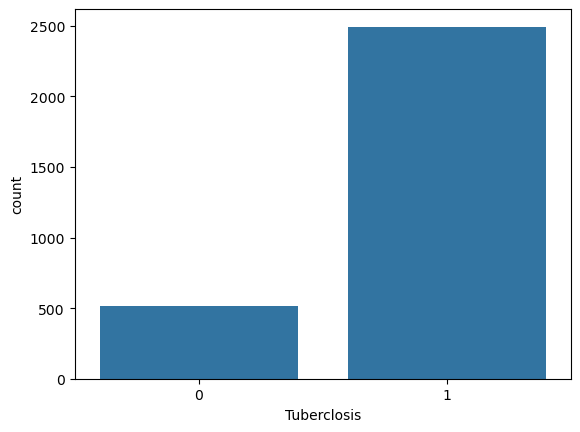

In [10]:
sns.countplot(image_df,x='Tuberclosis')

<Axes: xlabel='Width', ylabel='Height'>

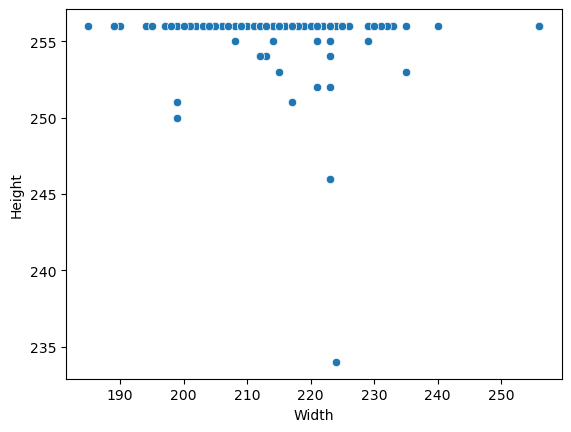

In [11]:
sns.scatterplot(image_df,x='Width',y='Height')

In [12]:
import torchvision
import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
from torch import nn
from torch import optim

In [13]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650


In [14]:
transform = transforms.Compose([transforms.Resize((256,256)),transforms.CenterCrop((224,224)),transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

In [15]:
Imagedata = ImageFolder(r'Dataset',transform=transform)


In [16]:
classes = Imagedata.class_to_idx
print(classes)

{'Normal_chest': 0, 'Tuberclosis_chest': 1}


In [17]:
print(len(Imagedata))

3008


In [18]:
train_size = int(len(Imagedata)*0.8)
test_size = len(Imagedata)-train_size

In [19]:
train_data,test_data = random_split(Imagedata,[train_size,test_size])

In [20]:
train_loader =  DataLoader(train_data,batch_size=2,shuffle=True)
test_loader = DataLoader(test_data,batch_size=1,shuffle=True)

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
import torchvision.models as models

In [23]:
resnet50 = models.resnet50(pretrained=True)
print(resnet50.fc)

d:\conda_env\my_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\conda_env\my_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Linear(in_features=2048, out_features=1000, bias=True)


In [24]:
resnet50.fc = nn.Linear(resnet50.fc.in_features,1)
print(resnet50.fc)
resnet50.to(device)

Linear(in_features=2048, out_features=1, bias=True)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [25]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet50.parameters(),lr=0.001)

In [26]:
from torchmetrics import Precision,Recall,Accuracy,F1Score

In [27]:
met_acc = Accuracy(task='binary')
met_acc.to(device)

BinaryAccuracy()

In [28]:
image,label = next(iter(train_loader))
image,label=image.to(device),label.to(device)

In [29]:
op = resnet50(image)
label= label.unsqueeze(1).float()

In [30]:
met_acc(op,label)

tensor(0., device='cuda:0')

In [31]:
best_val_acc = float(0)
patience = 2
trigger_times = 0
train_acc = []
test_acc = []

In [32]:
for epoch in range(10):
    met_acc = Accuracy(task='binary')
    met_acc.to(device)
    resnet50.train()
    for image,label in train_loader:
        image,label=image.to(device),label.to(device)
        optimizer.zero_grad()
        outputs = resnet50(image)
        label= label.unsqueeze(1).float()
        loss = criterion(outputs,label)
        met_acc(outputs,label)
        loss.backward()
        optimizer.step()
    epoch_acc = met_acc.compute()
    train_acc.append(epoch_acc)
    resnet50.eval()
    with torch.no_grad():
        for image,label in test_loader:
            image,label = image.to(device),label.to(device)
            output = resnet50(image)
            label = label.unsqueeze(1).float()
            met_acc(output,label)
    accuracy = met_acc.compute()
    test_acc.append(accuracy)
    if accuracy>best_val_acc:
        best_val_acc = accuracy
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >=patience:
            print('Early Stopping')
            break
    print(f'epoch:{epoch}')


epoch:0
epoch:1
epoch:2
epoch:3
epoch:4
epoch:5
epoch:6
epoch:7
Early Stopping


In [33]:
train_acc = [i.cpu() for i in train_acc]
test_acc = [i.cpu() for i in test_acc]

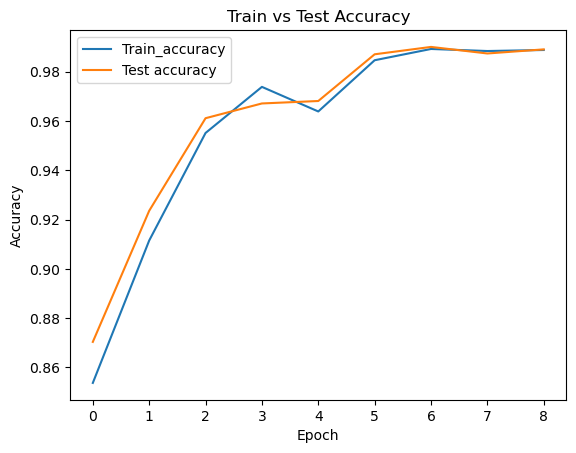

In [34]:
plt.plot(train_acc,label='Train_accuracy')
plt.plot(test_acc,label = 'Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()

In [35]:
met_prec = Precision(task='binary',average='macro')
met_prec.to(device)
met_rec = Recall(task='binary',average='macro')
met_rec.to(device)
met_acc = Accuracy(task='binary')
met_acc.to(device)
met_f1 = F1Score(task='binary')
met_f1.to(device)
with torch.no_grad():
    for image,label in test_loader:
        image,label = image.to(device),label.to(device)
        output = resnet50(image)
        label = label.unsqueeze(1).float()
        met_prec(output,label)
        met_rec(output,label)
        met_acc(output,label)
        met_f1(output,label)
precision = met_prec.compute()
recall = met_rec.compute()
accuracy = met_acc.compute()
F1_score = met_f1.compute()
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Accuracy: {accuracy}')
print(f'F1 Score: {F1_score}')
    

Precision: 0.993914783000946
Recall: 0.993914783000946
Accuracy: 0.9900332093238831
F1 Score: 0.993914783000946


In [78]:
torch.save(resnet50,'TB_Detector.sav')

In [36]:
vgg16 = models.vgg16(pretrained=True)

d:\conda_env\my_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [37]:
print(vgg16.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [38]:
vgg16.classifier[6]=nn.Linear(4096,1)

In [39]:
vgg16.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [40]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(vgg16.parameters(),lr=0.001)

In [41]:
best_val_acc = float(0)
patience = 3
trigger_times = 0
train_acc = []
test_acc = []

In [42]:
for epoch in range(10):
    met_acc = Accuracy(task='binary')
    met_acc.to(device)
    vgg16.train()
    for image,label in train_loader:
        image,label=image.to(device),label.to(device)
        optimizer.zero_grad()
        outputs = vgg16(image)
        label= label.unsqueeze(1).float()
        loss = criterion(outputs,label)
        met_acc(outputs,label)
        loss.backward()
        optimizer.step()
    epoch_acc = met_acc.compute()
    train_acc.append(epoch_acc)
    vgg16.eval()
    with torch.no_grad():
        for image,label in test_loader:
            image,label = image.to(device),label.to(device)
            output = vgg16(image)
            label = label.unsqueeze(1).float()
            met_acc(output,label)
    accuracy = met_acc.compute()
    test_acc.append(accuracy)
    if accuracy>best_val_acc:
        best_val_acc = accuracy
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >=patience:
            print('Early Stopping')
            break
    print(f'epoch:{epoch}')


epoch:0
epoch:1
epoch:2
epoch:3
Early Stopping


In [43]:
train_acc = [i.cpu() for i in train_acc]
test_acc = [i.cpu() for i in test_acc]

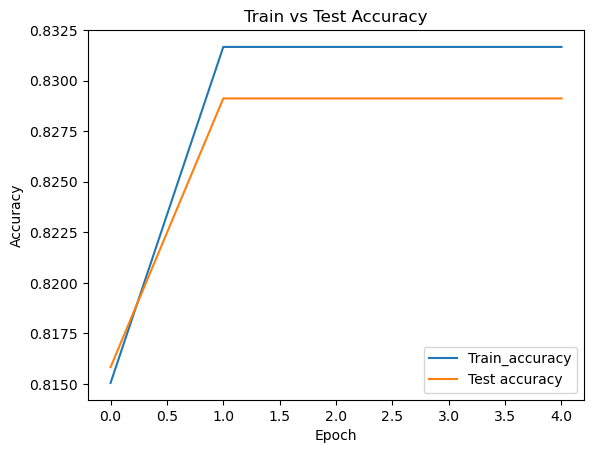

In [44]:
plt.plot(train_acc,label='Train_accuracy')
plt.plot(test_acc,label = 'Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()

In [45]:
met_prec = Precision(task='binary',average='macro')
met_prec.to(device)
met_rec = Recall(task='binary',average='macro')
met_rec.to(device)
met_acc = Accuracy(task='binary')
met_acc.to(device)
met_f1 = F1Score(task='binary')
met_f1.to(device)
with torch.no_grad():
    for image,label in test_loader:
        image,label = image.to(device),label.to(device)
        output = vgg16(image)
        label = label.unsqueeze(1).float()
        met_prec(output,label)
        met_rec(output,label)
        met_acc(output,label)
        met_f1(output,label)
precision = met_prec.compute()
recall = met_rec.compute()
accuracy = met_acc.compute()
F1_score = met_f1.compute()
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Accuracy: {accuracy}')
print(f'F1 Score: {F1_score}')

Precision: 0.8189368844032288
Recall: 1.0
Accuracy: 0.8189368844032288
F1 Score: 0.9004566073417664


In [68]:
effnet = models.efficientnet_b0(pretrained=False)

d:\conda_env\my_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\conda_env\my_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [57]:
print(effnet.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [69]:
effnet.classifier[1]=nn.Linear(effnet.classifier[1].in_features,1)

In [70]:
print(effnet.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [71]:
effnet.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [72]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(effnet.parameters(),lr=0.002)
best_val_acc = float(0)
patience = 5
trigger_times = 0
train_acc = []
test_acc = []

In [73]:
for epoch in range(10):
    met_acc = Accuracy(task='binary')
    met_acc.to(device)
    effnet.train()
    for image,label in train_loader:
        image,label=image.to(device),label.to(device)
        optimizer.zero_grad()
        outputs = vgg16(image)
        label= label.unsqueeze(1).float()
        loss = criterion(outputs,label)
        met_acc(outputs,label)
        loss.backward()
        optimizer.step()
    epoch_acc = met_acc.compute()
    train_acc.append(epoch_acc)
    effnet.eval()
    with torch.no_grad():
        for image,label in test_loader:
            image,label = image.to(device),label.to(device)
            output = effnet(image)
            label = label.unsqueeze(1).float()
            met_acc(output,label)
    accuracy = met_acc.compute()
    test_acc.append(accuracy)
    if accuracy>best_val_acc:
        best_val_acc = accuracy
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >=patience:
            print('Early Stopping')
            break
    print(f'epoch:{epoch}')


epoch:0
epoch:1
epoch:2
epoch:3
epoch:4
Early Stopping


In [74]:
train_acc = [i.cpu() for i in train_acc]
test_acc = [i.cpu() for i in test_acc]

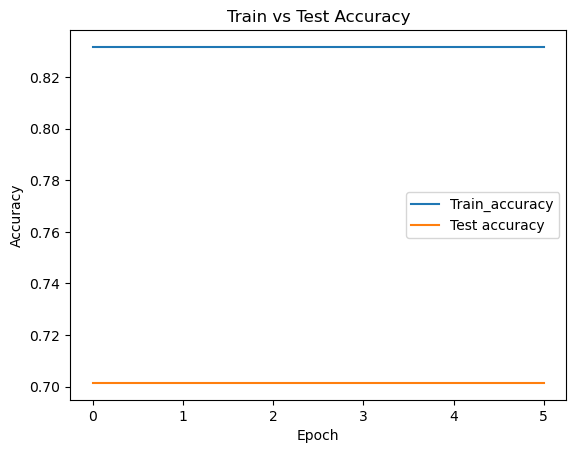

In [75]:
plt.plot(train_acc,label='Train_accuracy')
plt.plot(test_acc,label = 'Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()

In [76]:
met_prec = Precision(task='binary',average='macro')
met_prec.to(device)
met_rec = Recall(task='binary',average='macro')
met_rec.to(device)
met_acc = Accuracy(task='binary')
met_acc.to(device)
met_f1 = F1Score(task='binary')
met_f1.to(device)
with torch.no_grad():
    for image,label in test_loader:
        image,label = image.to(device),label.to(device)
        output = vgg16(image)
        label = label.unsqueeze(1).float()
        met_prec(output,label)
        met_rec(output,label)
        met_acc(output,label)
        met_f1(output,label)
precision = met_prec.compute()
recall = met_rec.compute()
accuracy = met_acc.compute()
F1_score = met_f1.compute()
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Accuracy: {accuracy}')
print(f'F1 Score: {F1_score}')

Precision: 0.8189368844032288
Recall: 1.0
Accuracy: 0.8189368844032288
F1 Score: 0.9004566073417664


In [80]:
resnet_X = torch.load('TB_Detector.sav',weights_only=False)

In [81]:
met_prec = Precision(task='binary',average='macro')
met_prec.to(device)
met_rec = Recall(task='binary',average='macro')
met_rec.to(device)
met_acc = Accuracy(task='binary')
met_acc.to(device)
met_f1 = F1Score(task='binary')
met_f1.to(device)
resnet_X.eval()
with torch.no_grad():
    for image,label in test_loader:
        image,label = image.to(device),label.to(device)
        output = resnet_X(image)
        label = label.unsqueeze(1).float()
        met_prec(output,label)
        met_rec(output,label)
        met_acc(output,label)
        met_f1(output,label)
precision = met_prec.compute()
recall = met_rec.compute()
accuracy = met_acc.compute()
F1_score = met_f1.compute()
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Accuracy: {accuracy}')
print(f'F1 Score: {F1_score}')

Precision: 0.993914783000946
Recall: 0.993914783000946
Accuracy: 0.9900332093238831
F1 Score: 0.993914783000946
